In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

In [2]:
df = pd.read_csv("/content/diabetes.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nInfo:")
df.info()
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int6

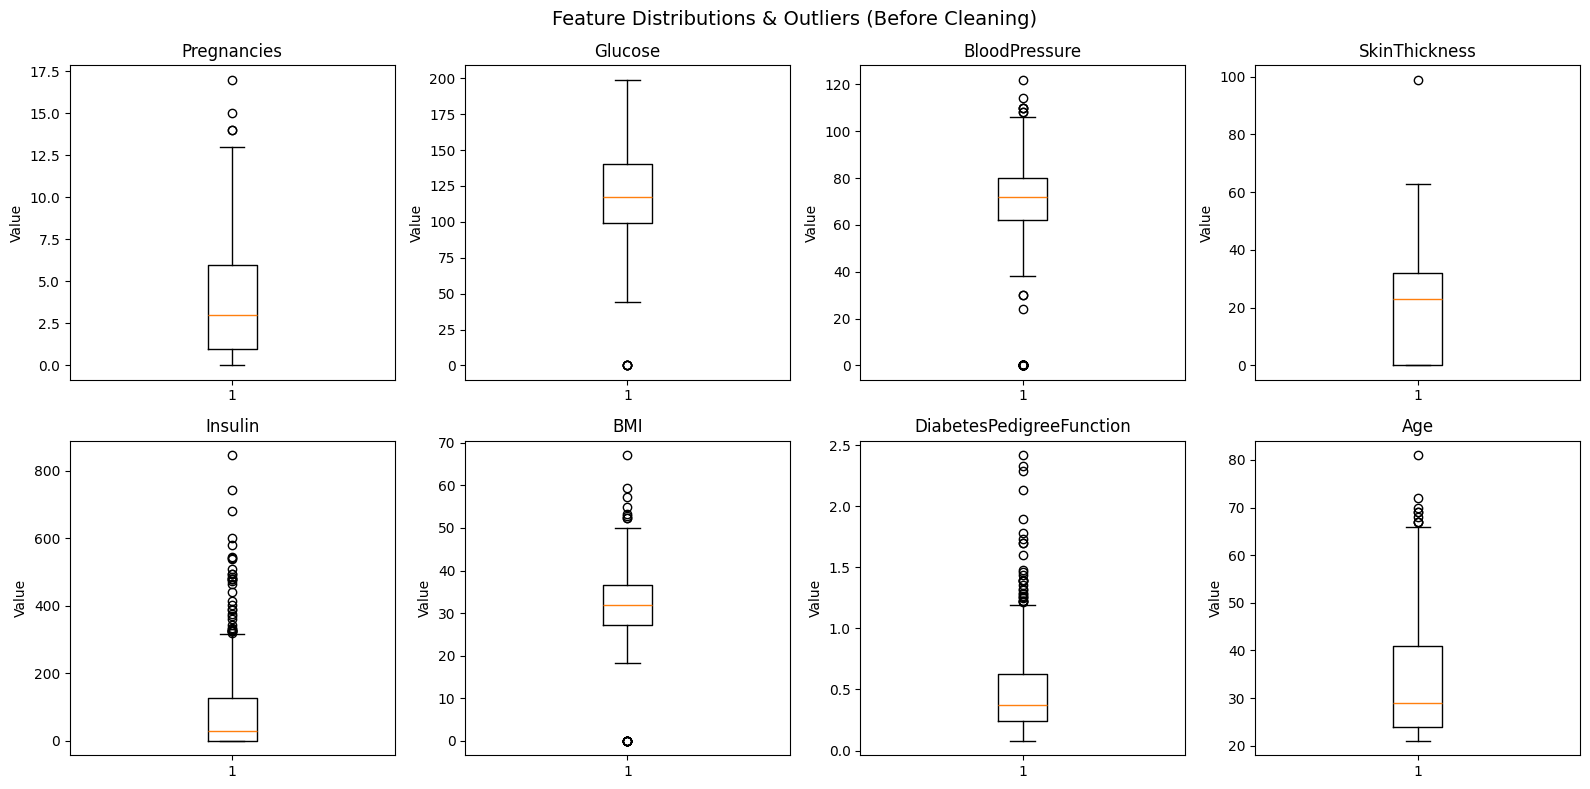

Outlier Analysis:
  Pregnancies          → 4 outliers
  Glucose              → 5 outliers
  BloodPressure        → 45 outliers
  SkinThickness        → 1 outliers
  Insulin              → 34 outliers
  BMI                  → 19 outliers
  DiabetesPedigreeFunction → 29 outliers
  Age                  → 9 outliers


In [3]:
# Visualize distributions and outliers before any cleaning
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Feature Distributions & Outliers (Before Cleaning)", fontsize=14)

for i, col in enumerate(df.columns[:-1]):  # exclude target column
    row = i // 4
    col_idx = i % 4
    axes[row][col_idx].boxplot(df[col])
    axes[row][col_idx].set_title(col)
    axes[row][col_idx].set_ylabel("Value")

plt.tight_layout()
plt.show()

# Print outlier counts per column
print("Outlier Analysis:")
for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col:20s} → {len(outliers)} outliers")

In [6]:
zero_not_allowed = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace impossible zeros with NaN
df[zero_not_allowed] = df[zero_not_allowed].replace(0, np.nan)



# Use mean for columns with few/no outliers
mean_cols   = ["Glucose", "SkinThickness"]

# Use median for columns with significant outliers
median_cols = ["BloodPressure", "Insulin", "BMI"]

for col in mean_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df.isnull().sum())
print("\nData after cleaning:")
print(df.describe())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data after cleaning:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.686763      72.386719      29.153420  140.671875   
std       3.369578   30.435949      12.096642       8.790942   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.153420  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.

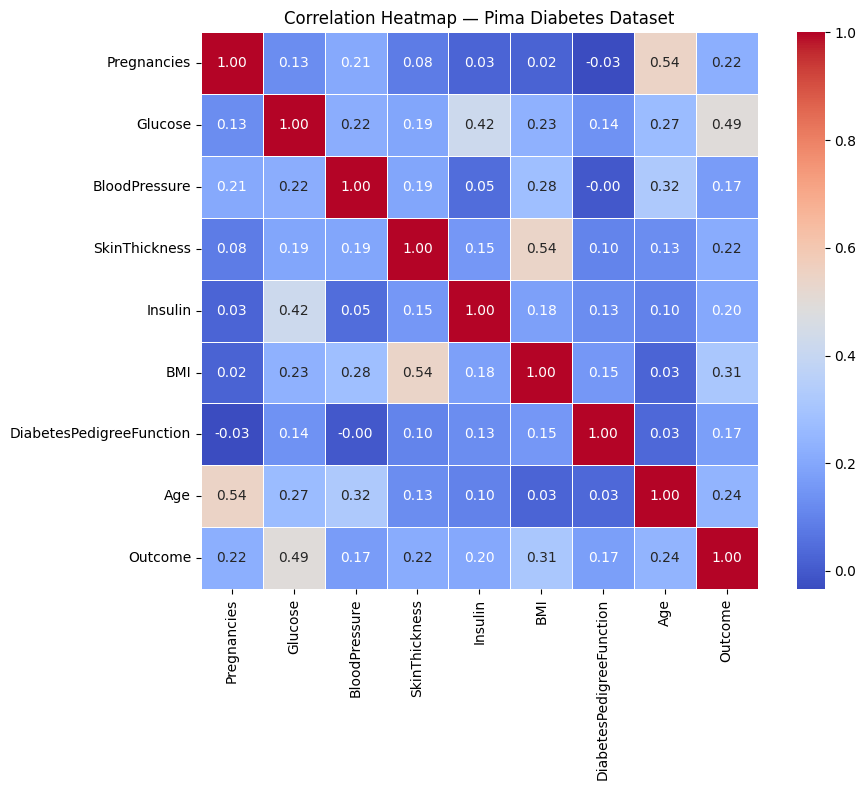

Highly correlated feature pairs (|correlation| > 0.5):
  Pregnancies               vs Age                       → 0.54
  SkinThickness             vs BMI                       → 0.54


In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Pima Diabetes Dataset")
plt.tight_layout()
plt.show()

# Print highly correlated pairs (threshold > 0.5)
print("Highly correlated feature pairs (|correlation| > 0.5):")
corr_matrix = df.corr().abs()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.5:
            print(f"  {corr_matrix.columns[i]:25s} vs {corr_matrix.columns[j]:25s} → {corr_matrix.iloc[i,j]:.2f}")

In [9]:
# Separate features and target
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# STEP 1: Split FIRST before any transformation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 2: Scale — fit_transform on train, transform on test only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# STEP 3: PCA — fit_transform on train, transform on test only
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"\nOriginal shape   : {X_train_scaled.shape}")
print(f"Reduced shape    : {X_train_pca.shape}")
print(f"Components kept  : {pca.n_components_}")
print(f"Variance retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Training samples : 614
Testing  samples : 154

Original shape   : (614, 8)
Reduced shape    : (614, 7)
Components kept  : 7
Variance retained: 95.13%


In [10]:
# Test all kernels before deciding which SVM to use
svm_kernels = {
    "SVM Linear"  : SVC(kernel="linear", random_state=42),
    "SVM RBF"     : SVC(kernel="rbf", random_state=42),
    "SVM Poly"    : SVC(kernel="poly", degree=3, random_state=42),
    "SVM Sigmoid" : SVC(kernel="sigmoid", random_state=42)
}

print("SVM Kernel Comparison:")
print(f"{'Kernel':<15} {'PCA Accuracy':>15} {'Original Accuracy':>18}")
print("-" * 52)

best_kernel_name = None
best_kernel_acc  = 0
best_kernel_obj  = None

for name, svm_model in svm_kernels.items():
    # On PCA data
    svm_model.fit(X_train_pca, y_train)
    pca_acc = accuracy_score(y_test, svm_model.predict(X_test_pca)) * 100

    # On original scaled data
    svm_model.fit(X_train_scaled, y_train)
    orig_acc = accuracy_score(y_test, svm_model.predict(X_test_scaled)) * 100

    print(f"{name:<15} {pca_acc:>14.2f}% {orig_acc:>17.2f}%")

    # Track best kernel based on original scaled accuracy
    if orig_acc > best_kernel_acc:
        best_kernel_acc  = orig_acc
        best_kernel_name = name
        best_kernel_obj  = SVC(
            kernel=name.split()[1].lower(),
            random_state=42,
            probability=True
        )

print(f"\nBest SVM Kernel: {best_kernel_name} ({best_kernel_acc:.2f}%)")
print("This kernel will be used in the final model comparison.")

SVM Kernel Comparison:
Kernel             PCA Accuracy  Original Accuracy
----------------------------------------------------
SVM Linear               70.13%             70.13%
SVM RBF                  74.68%             74.03%
SVM Poly                 72.08%             71.43%
SVM Sigmoid              70.78%             70.13%

Best SVM Kernel: SVM RBF (74.03%)
This kernel will be used in the final model comparison.


In [11]:
# Define all 5 models — SVM uses RBF (justified by Cell 7)
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)"          : SVC(kernel="rbf", random_state=42, probability=True),
    "KNN"                : KNeighborsClassifier(n_neighbors=5)
}

results_pca      = {}
results_original = {}

for name, model in models.items():
    # On PCA data
    model.fit(X_train_pca, y_train)
    results_pca[name] = accuracy_score(y_test, model.predict(X_test_pca)) * 100

    # On original scaled data
    model.fit(X_train_scaled, y_train)
    results_original[name] = accuracy_score(y_test, model.predict(X_test_scaled)) * 100

# Print comparison table
print(f"{'Model':<25} {'PCA Accuracy':>15} {'Original Accuracy':>18} {'Winner':>10}")
print("-" * 72)
for name in models:
    pca_acc  = results_pca[name]
    orig_acc = results_original[name]
    winner   = "PCA" if pca_acc > orig_acc else "Original" if orig_acc > pca_acc else "Tie"
    print(f"{name:<25} {pca_acc:>14.2f}% {orig_acc:>17.2f}% {winner:>10}")

best_model_name = max(results_original, key=results_original.get)
print(f"\nBest Overall Model: {best_model_name} ({results_original[best_model_name]:.2f}%)")

Model                        PCA Accuracy  Original Accuracy     Winner
------------------------------------------------------------------------
Logistic Regression                69.48%             70.78%   Original
Decision Tree                      70.78%             67.53%        PCA
Random Forest                      68.83%             75.32%   Original
SVM (RBF)                          74.68%             74.03%        PCA
KNN                                74.68%             75.32%   Original

Best Overall Model: Random Forest (75.32%)


Best Model: Random Forest
Accuracy  : 75.32%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.85      0.82       100
    Diabetes       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



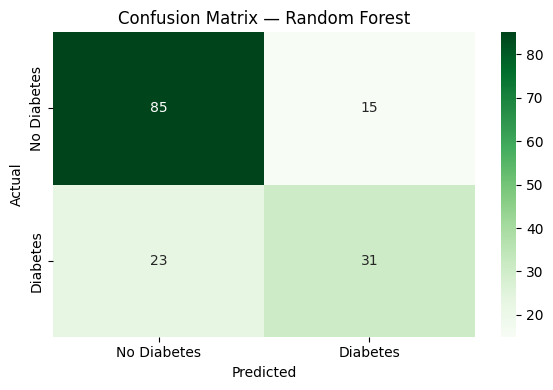

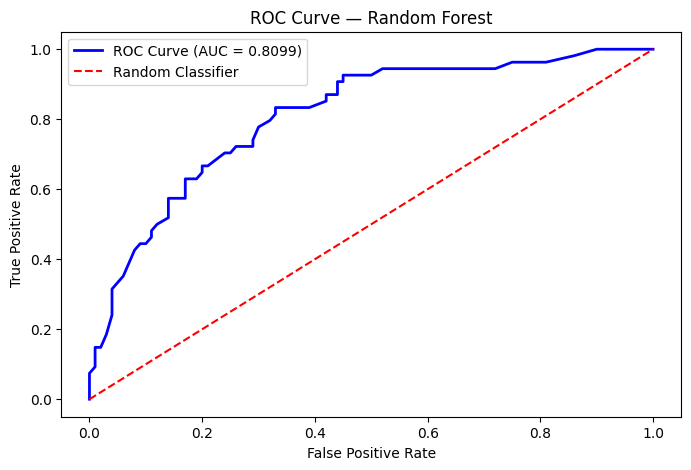

AUC Score: 0.8099


In [12]:
# Retrain best model on original scaled data
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Accuracy
print(f"Best Model: Random Forest")
print(f"Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Classifier")
plt.title("ROC Curve — Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth"    : [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

# scoring="recall" — optimize for catching diabetes patients
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="recall",   # prioritize recall over accuracy
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV Recall  : {grid_search.best_score_*100:.2f}%")

# Evaluate tuned model
best_tuned = grid_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test_scaled)

print(f"\nTuned Model Results:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print(classification_report(y_test, y_pred_tuned,
      target_names=["No Diabetes", "Diabetes"]))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Recall  : 60.31%

Tuned Model Results:
Accuracy : 75.32%
              precision    recall  f1-score   support

 No Diabetes       0.79      0.85      0.82       100
    Diabetes       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



In [16]:
# Fix class imbalance using class_weight='balanced'
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = rf_balanced.predict(X_test_scaled)

print("Results after Class Imbalance Fix:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_balanced)*100:.2f}%")
print(classification_report(y_test, y_pred_balanced,
      target_names=["No Diabetes", "Diabetes"]))

# Compare Recall before and after fix
report_before = 0.57
report_after  = classification_report(
    y_test, y_pred_balanced,
    target_names=["No Diabetes", "Diabetes"],
    output_dict=True
)["Diabetes"]["recall"]

print("Recall Comparison:")
print(f"  Before fix : {report_before:.2f} (57% diabetes patients caught)")
print(f"  After fix  : {report_after:.2f} ({report_after*100:.0f}% diabetes patients caught)")

Results after Class Imbalance Fix:
Accuracy : 73.38%
              precision    recall  f1-score   support

 No Diabetes       0.78      0.83      0.80       100
    Diabetes       0.64      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154

Recall Comparison:
  Before fix : 0.57 (57% diabetes patients caught)
  After fix  : 0.56 (56% diabetes patients caught)


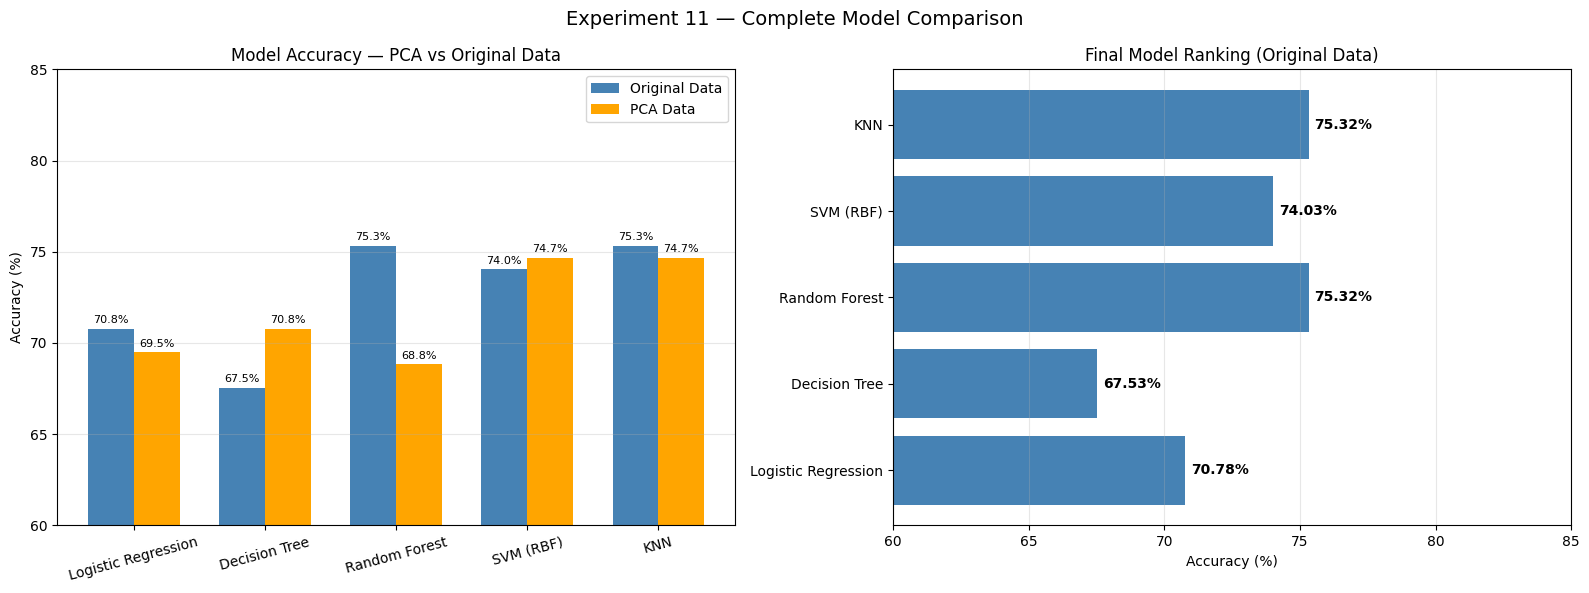


Final Summary:
Model                       Original        PCA     Winner
-------------------------------------------------------
Logistic Regression           70.78%     69.48%   Original
Decision Tree                 67.53%     70.78%        PCA
Random Forest                 75.32%     68.83%   Original
SVM (RBF)                     74.03%     74.68%        PCA
KNN                           75.32%     74.68%   Original

Conclusion: Random Forest & KNN tied as best models at 75.32%
PCA was NOT beneficial for this dataset — original data performed better for 3/5 models
Root cause: Low feature correlation (max 0.54) — confirmed by heatmap in Cell 5


In [17]:
# Final comparison bar chart
models_names = list(results_original.keys())
original_accs = list(results_original.values())
pca_accs      = list(results_pca.values())

x = np.arange(len(models_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — PCA vs Original accuracy
axes[0].bar(x - width/2, original_accs, width, label="Original Data", color="steelblue")
axes[0].bar(x + width/2, pca_accs,      width, label="PCA Data",      color="orange")
axes[0].set_title("Model Accuracy — PCA vs Original Data")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names, rotation=15)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(60, 85)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")
for i, (o, p) in enumerate(zip(original_accs, pca_accs)):
    axes[0].text(i - width/2, o + 0.3, f"{o:.1f}%", ha="center", fontsize=8)
    axes[0].text(i + width/2, p + 0.3, f"{p:.1f}%", ha="center", fontsize=8)

# Horizontal bar chart — best accuracy per model
axes[1].barh(models_names, original_accs, color="steelblue")
axes[1].set_title("Final Model Ranking (Original Data)")
axes[1].set_xlabel("Accuracy (%)")
axes[1].set_xlim(60, 85)
axes[1].grid(True, alpha=0.3, axis="x")
for i, acc in enumerate(original_accs):
    axes[1].text(acc + 0.2, i, f"{acc:.2f}%", va="center", fontweight="bold")

plt.suptitle("Experiment 11 — Complete Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

# Final summary
print("\nFinal Summary:")
print(f"{'Model':<25} {'Original':>10} {'PCA':>10} {'Winner':>10}")
print("-" * 55)
for name in models_names:
    o = results_original[name]
    p = results_pca[name]
    w = "PCA" if p > o else "Original" if o > p else "Tie"
    print(f"{name:<25} {o:>9.2f}% {p:>9.2f}% {w:>10}")

print(f"\nConclusion: Random Forest & KNN tied as best models at 75.32%")
print(f"PCA was NOT beneficial for this dataset — original data performed better for 3/5 models")
print(f"Root cause: Low feature correlation (max 0.54) — confirmed by heatmap in Cell 5")